In [ ]:
# Code cell
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt  # Fixed typo: 'matlpotlib' -> 'matplotlib'
import warnings
warnings.filterwarnings('ignore')


In [1]:
# Load dataset
df=pd.read_csv('insurance.csv')
df

NameError: name 'pd' is not defined

In [3]:
# Code cell
#EDA

In [4]:
# Quick dataset inspection
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [5]:
# Code cell
df.shape

(1338, 7)

In [6]:
# Code cell
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [7]:
# Quick dataset inspection
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [8]:
# Code cell
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [9]:
# Code cell
#DATA VISUALIZATION

In [10]:
# Code cell
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

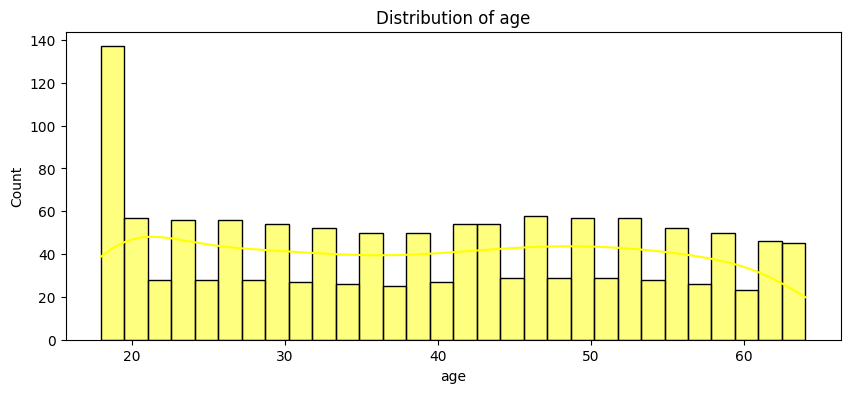

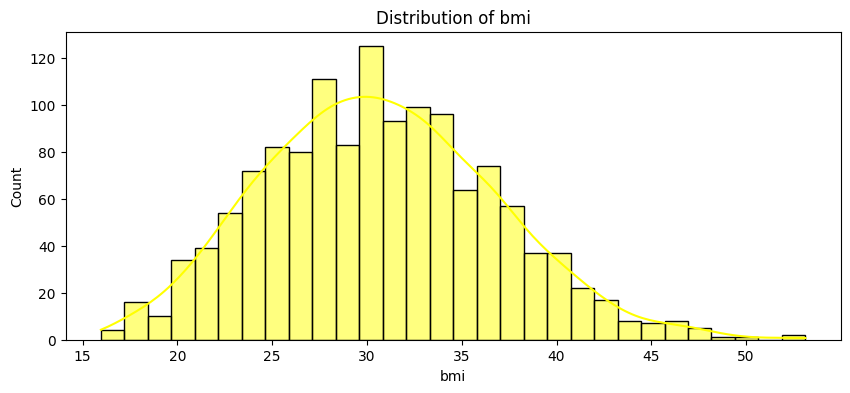

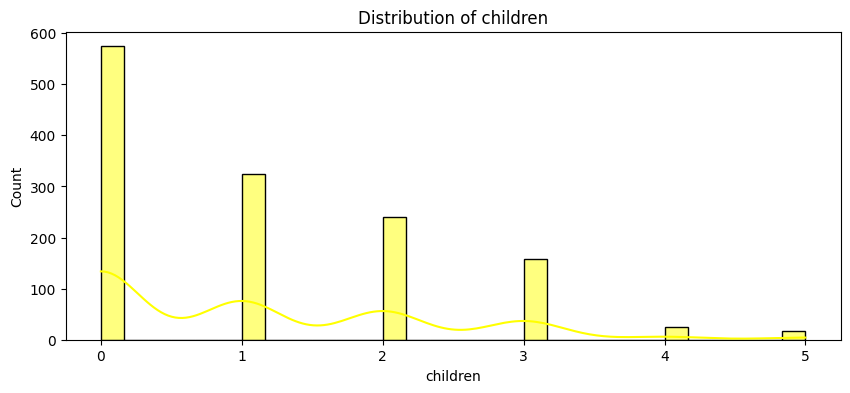

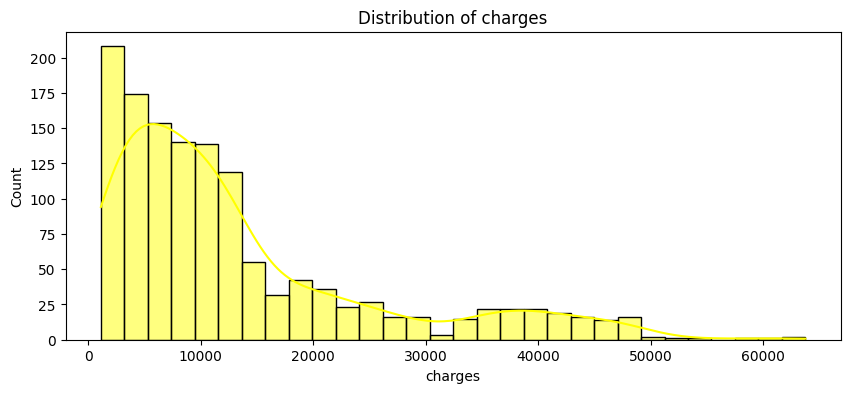

In [11]:
# Data visualization
numeric_col=['age','bmi','children','charges']
for col in numeric_col:
  plt.figure(figsize=(10,4))
  sns.histplot(df[col],kde=True,color='yellow',bins=30)
  plt.title(f'Distribution of {col}')
  plt.xlabel(col)
  plt.ylabel('Count')
  plt.show()

<Axes: xlabel='sex', ylabel='count'>

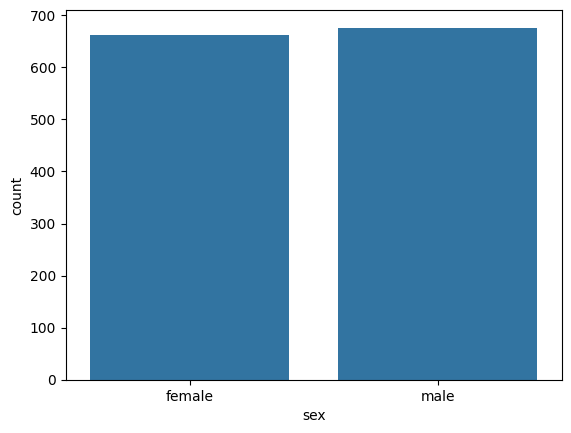

In [12]:
# Data visualization
sns.countplot(x=df['sex'])

<Axes: xlabel='smoker', ylabel='count'>

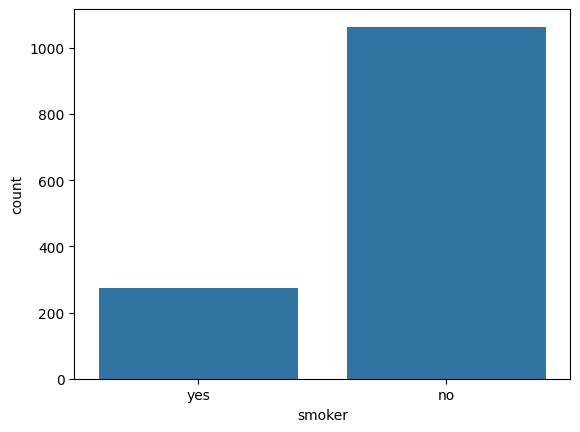

In [13]:
# Data visualization
sns.countplot(x=df['smoker'])

<Axes: xlabel='region', ylabel='count'>

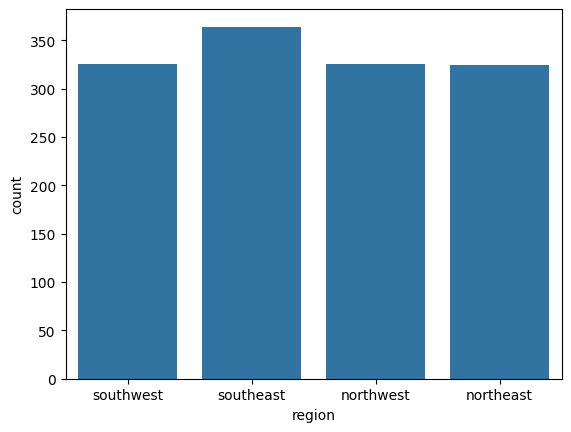

In [14]:
# Data visualization
sns.countplot(x=df['region'])

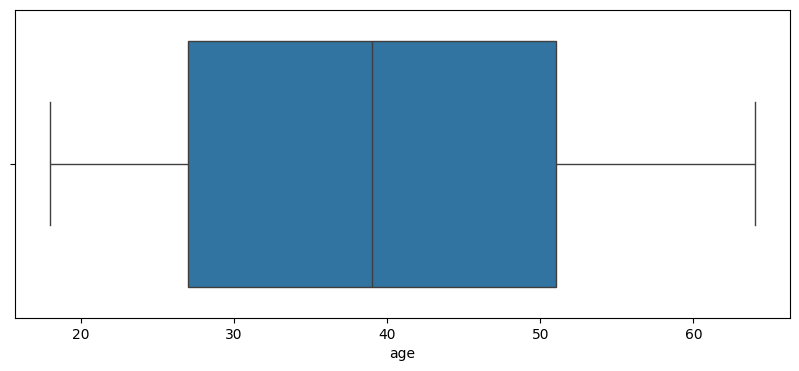

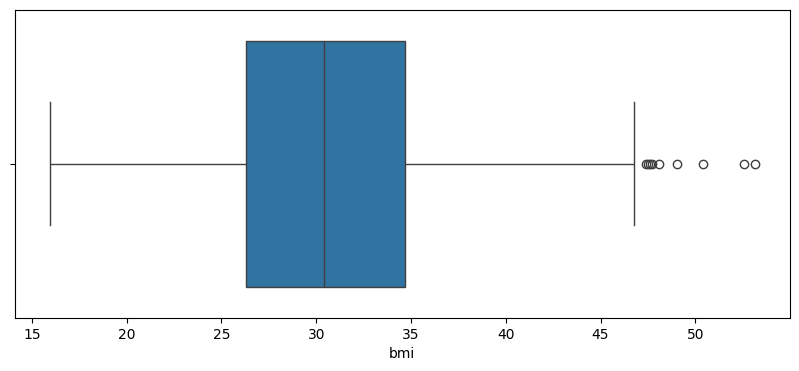

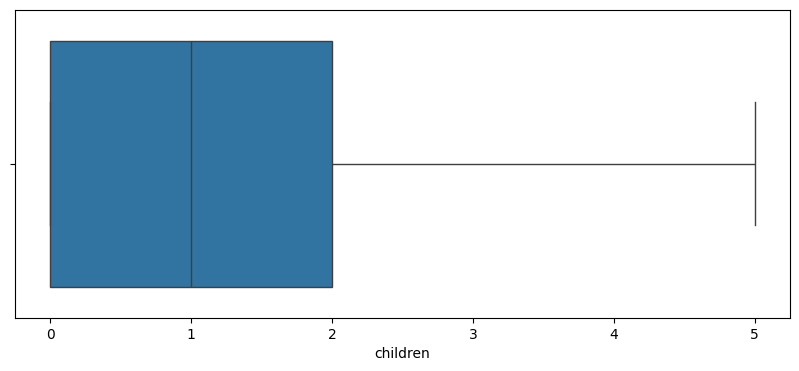

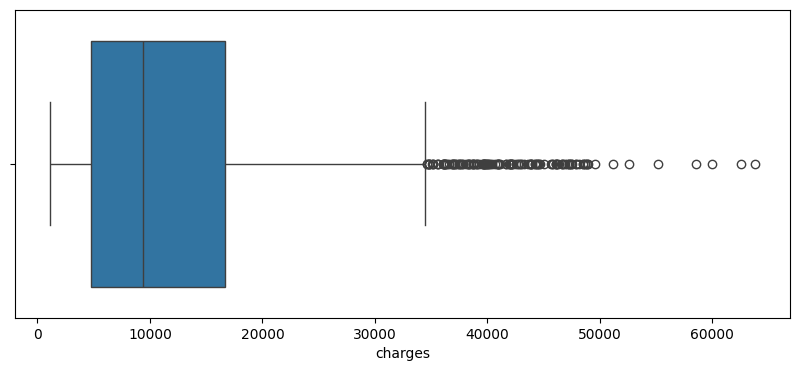

In [15]:
# Data visualization
for col in numeric_col:
  plt.figure(figsize=(10,4))
  sns.boxplot(x=df[col])
  plt.xlabel(col)


<Axes: >

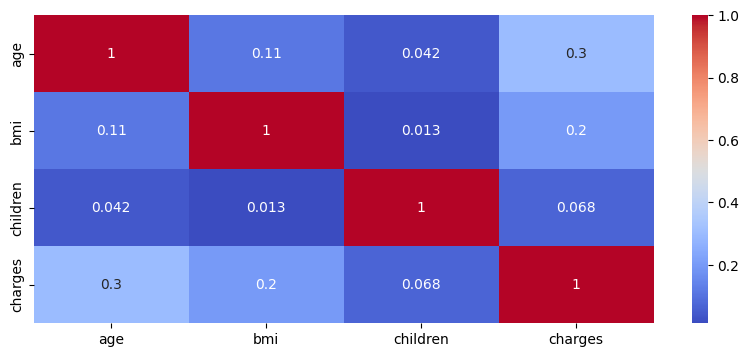

In [16]:
# Data visualization
plt.figure(figsize=(10,4))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')


In [17]:
# Code cell
#Data cleaning and preprocessing

In [18]:
# Code cell
df_cleaned=df.copy()

In [19]:
# Data cleaning / preprocessing
df_cleaned.drop_duplicates(inplace=True)

In [20]:
# Code cell

df_cleaned.shape

(1337, 7)

In [21]:
# Code cell
df_cleaned.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


In [22]:
# Code cell
df_cleaned['sex'].value_counts()


,count
sex,
male,675
female,662


In [23]:
# Code cell
df_cleaned['sex']=df_cleaned['sex'].map({'male':0,'female':1})

In [24]:
# Code cell
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520


In [25]:
# Code cell
df_cleaned['smoker'].value_counts()

,count
smoker,
no,1063
yes,274


In [26]:
# Code cell
df_cleaned['smoker']=df_cleaned['smoker'].map({'no': 0,'yes':1})

In [27]:
# Code cell
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [28]:
# Code cell
df_cleaned.rename(columns={
    'sex':'is_female',
    'smoker':'is_smoker'
},inplace=True)


In [29]:
# Code cell
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [30]:
# Code cell
df_cleaned['region'].value_counts()

,count
region,
southeast,364
southwest,325
northwest,324
northeast,324


In [31]:
# Encode categorical features
df_cleaned=pd.get_dummies(df_cleaned,columns=['region'],drop_first=True)

In [32]:
# Code cell
df_cleaned=df_cleaned.astype(int)

In [33]:
# Code cell
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,1
1,18,0,33,1,0,1725,0,1,0
2,28,0,33,3,0,4449,0,1,0
3,33,0,22,0,0,21984,1,0,0
4,32,0,28,0,0,3866,1,0,0


In [34]:
# Code cell
#Feature Engineering And Extraction

In [35]:
# Code cell
df_cleaned['bmi_category']=pd.cut(df_cleaned['bmi'],bins=[0,18.5,24.9,29.9,float('inf')],
                                  labels=['underweight','normal','overweight','obesity'])

In [36]:
# Code cell
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category
0,19,1,27,0,1,16884,0,0,1,overweight
1,18,0,33,1,0,1725,0,1,0,obesity
2,28,0,33,3,0,4449,0,1,0,obesity
3,33,0,22,0,0,21984,1,0,0,normal
4,32,0,28,0,0,3866,1,0,0,overweight


In [37]:
# Encode categorical features
df_cleaned=pd.get_dummies(df_cleaned,columns=['bmi_category'],drop_first=True)

In [38]:
# Code cell
df_cleaned=df_cleaned.astype(int)

In [39]:
# Code cell
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_normal,bmi_category_overweight,bmi_category_obesity
0,19,1,27,0,1,16884,0,0,1,0,1,0
1,18,0,33,1,0,1725,0,1,0,0,0,1
2,28,0,33,3,0,4449,0,1,0,0,0,1
3,33,0,22,0,0,21984,1,0,0,1,0,0
4,32,0,28,0,0,3866,1,0,0,0,1,0


In [40]:
# Feature scaling
from sklearn.preprocessing import StandardScaler

In [41]:
# Feature scaling
cols=['bmi','age','children']
scaler=StandardScaler()
df_cleaned[cols]=scaler.fit_transform(df_cleaned[cols])

In [42]:
# Code cell
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_normal,bmi_category_overweight,bmi_category_obesity
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0,1,0,1,0
1,-1.511647,0,0.462463,-0.079442,0,1725,0,1,0,0,0,1
2,-0.799350,0,0.462463,1.580143,0,4449,0,1,0,0,0,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,1,0,0,1,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,1,0,0,0,1,0


In [43]:
# Code cell
from scipy.stats import pearsonr
#Pearson corelation test
selected_features=['age','bmi','children','is_female','is_smoker','region_northwest','region_southeast','region_southwest',
                   'bmi_category_normal','bmi_category_overweight','bmi_category_obesity']

correlations={
    feature:pearsonr(df_cleaned[feature],df_cleaned['charges'])[0]
    for feature in selected_features
}
correlation_df=pd.DataFrame(list(correlations.items()),columns=['Features','Pearson Correlatons'])
correlation_df.sort_values(by='Pearson Correlatons',ascending=False)

,Features,Pearson Correlatons
4,is_smoker,0.787234
0,age,0.298309
10,bmi_category_obesity,0.200348
1,bmi,0.196236
6,region_southeast,0.073577
2,children,0.067390
5,region_northwest,-0.038695
7,region_southwest,-0.043637
3,is_female,-0.058046
8,bmi_category_normal,-0.104042


In [44]:
# Code cell
cat_features=[
    'is_female','is_smoker','region_northwest','region_southeast','region_southwest',
    'bmi_category_normal','bmi_category_overweight','bmi_category_obesity'
]

In [45]:
# Code cell
from scipy.stats import chi2_contingency
alpha=0.05

df_cleaned['charges_bin']=pd.qcut(df_cleaned['charges'],q=4,labels=False)
chi2_results={}
for feature in cat_features:
  contingency=pd.crosstab(df_cleaned[feature],df_cleaned['charges_bin'])
  chi2_stat,p_value,_,_=chi2_contingency(contingency)
  decision='Reject Null Hypothesis' if p_value<alpha else 'Fail to Reject Null Hypothesis'
  chi2_results[feature]={
      'Chi2_stat':chi2_stat,
      'p_value':p_value,
      'Decision':decision
  }
chi2_results_df=pd.DataFrame(chi2_results).T
chi2_results_df.sort_values(by='p_value')

,Chi2_stat,p_value,Decision
is_smoker,848.219178,0.0,Reject Null Hypothesis
region_southeast,15.998167,0.001135,Reject Null Hypothesis
is_female,10.258784,0.01649,Reject Null Hypothesis
bmi_category_obesity,8.515711,0.036473,Reject Null Hypothesis
region_southwest,5.091893,0.165191,Fail to Reject Null Hypothesis
bmi_category_overweight,4.25149,0.235557,Fail to Reject Null Hypothesis
bmi_category_normal,3.708088,0.29476,Fail to Reject Null Hypothesis
region_northwest,1.13424,0.768815,Fail to Reject Null Hypothesis


In [46]:
# Code cell
final_df=df_cleaned[['age','is_smoker','bmi','children','charges',
                     'region_southeast','is_female','bmi_category_obesity']]

In [47]:
# Code cell
final_df

,age,is_smoker,bmi,children,charges,region_southeast,is_female,bmi_category_obesity
0,-1.440418,1,-0.517949,-0.909234,16884,0,1,0
1,-1.511647,0,0.462463,-0.079442,1725,1,0,1
2,-0.799350,0,0.462463,1.580143,4449,1,0,1
3,-0.443201,0,-1.334960,-0.909234,21984,0,0,0
4,-0.514431,0,-0.354547,-0.909234,3866,0,0,0
...,...,...,...,...,...,...,...,...
1333,0.767704,0,-0.027743,1.580143,10600,0,0,1
1334,-1.511647,0,0.135659,-0.909234,2205,0,1,1
1335,-1.511647,0,0.952670,-0.909234,1629,1,1,1
1336,-1.297958,0,-0.844753,-0.909234,2007,0,1,0


In [48]:
# Split data into train and test sets
from sklearn.model_selection import train_test_split


In [49]:
# Data cleaning / preprocessing
X=final_df.drop('charges',axis=1)
y=final_df['charges']

In [50]:
# Split data into train and test sets
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [51]:
# Build and train model
from sklearn.linear_model import LinearRegression

In [52]:
# Build and train model
model=LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [53]:
# Make predictions
y_predic=model.predict(X_test)

In [54]:
# Evaluate model performance
from sklearn.metrics import r2_score
r2=r2_score(y_test,y_predic)
r2
n=X_test.shape[0]
p=X_test.shape[1]
adj_r2=1-((1-r2)*(n-1)/(n-p-1))
adj_r2

0.7987962362937232